#  PROJECT OVERVIEW

### Business Context
This dataset contains all transactions from a UK-based non-store online retailer
between December 2009 and December 2011. The company sells unique all-occasion
gift-ware, with a significant portion of its customer base being wholesalers.

The goal of this analysis is to surface actionable insights around revenue
performance, customer behavior, and product demand to inform the company's
growth and retention strategy.

### Key Questions
1. How does revenue trend over time — are there seasonal patterns or growth periods?
2. Which countries drive the most revenue outside the UK?
3. Which products are the top and bottom performers by revenue and volume?
4. Are there anomalies in the data (cancellations, returns, negative quantities)
   that affect reported revenue?

*Note: Customer-level behavior analysis was excluded due to 243,007 missing 
Customer IDs (~22% of transactions), which would produce unreliable results.*


## Imports

In [102]:
# Imports
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Visualization settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

## Loading Data

In [103]:
# Loading Data

DATA_PATH = Path("../data/raw/online_retail.xlsx")

df_2009 = pd.read_excel(DATA_PATH, sheet_name="Year 2009-2010")
df_2010 = pd.read_excel(DATA_PATH, sheet_name="Year 2010-2011")

raw_data = pd.concat([df_2009, df_2010], ignore_index=True)

df = raw_data.copy()

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [104]:
# General Inspection

print('*** General info ***\n')
df.info()
print("\nShape:", df.shape)
print('\nColumn names:', df.columns)

*** General info ***

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 65.1+ MB

Shape: (1067371, 8)

Column names: Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='str')


In [105]:
# Unique value counts per column
for col in df.columns:
    print(f"{col}: {df[col].nunique():,} unique values")

Invoice: 53,628 unique values
StockCode: 5,305 unique values
Description: 5,698 unique values
Quantity: 1,057 unique values
InvoiceDate: 47,635 unique values
Price: 2,807 unique values
Customer ID: 5,942 unique values
Country: 43 unique values


## Preprocessing

In [106]:
# Checking For Missing Data

print('\n*** Missing values ***\n')
print(df.isna().sum())

# Checking For Duplicate Rows

duplicates = df.duplicated().sum()
print('\n*** Duplicated Rows ***\n\nAmount:', duplicates)



*** Missing values ***

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

*** Duplicated Rows ***

Amount: 34335


In [107]:
# Dropping Missing Values And Duplicates
# Keeping CustomerID Missing Values, Column Not Needed For Analysis But Rows Are Important
df.dropna(subset=['Description'], inplace=True)
df.drop_duplicates(inplace=True)

print(f'Shape After Cleaning: {df.shape}')

Shape After Cleaning: (1028761, 8)


In [108]:
# Standardizing Column Names

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r'[^0-9a-zA-Z]+', '_', regex=True)
    .str.strip('_')
)
df.columns.tolist()


['invoice',
 'stockcode',
 'description',
 'quantity',
 'invoicedate',
 'price',
 'customer_id',
 'country']

In [109]:
# Creating Revenue Column
df['revenue'] = df['price'] * df['quantity']

## Data Analysis

In [110]:
# Statistical Evaluation (Excluding Cancellations and Negative Quantities)

df_clean = df[(df['quantity'] > 0) & (df['revenue'] > 0)]


mean_revenue = stats.tmean(df_clean['revenue'])
median_revenue = stats.scoreatpercentile(df_clean['revenue'], 50)
std_revenue = stats.tstd(df_clean['revenue'])

mean_qty = stats.tmean(df_clean['quantity'])
median_qty = stats.scoreatpercentile(df_clean['quantity'], 50)
std_qty = stats.tstd(df_clean['quantity'])

print('*** Revenue ***\n')
print(f'Mean: {mean_revenue:.2f}, Median: {median_revenue:.2f}, Std: {std_revenue:.2f}')
print('\n*** Units ***\n')
print(f'Mean: {mean_qty:.2f}, Median: {median_qty:.2f}, Std: {std_qty:.2f}')

*** Revenue ***

Mean: 20.32, Median: 10.08, Std: 205.72

*** Units ***

Mean: 11.12, Median: 4.00, Std: 128.47


In [111]:
# Highest and Lowest Quantity Groups by Country

by_country_qty = df.groupby('country')['quantity'].sum().sort_values(ascending=False)
print('Highest Quantity Group:', by_country_qty.index[0])
print('\nLowest Quantity Group:', by_country_qty.index[-1])

by_country_qty

Highest Quantity Group: United Kingdom

Lowest Quantity Group: Nigeria


country
United Kingdom          8587949
Netherlands              381853
EIRE                     327431
Denmark                  234764
Germany                  221816
France                   181572
Australia                103375
Sweden                    87858
Switzerland               52256
Spain                     44667
Belgium                   34598
Japan                     30138
Portugal                  27368
Norway                    23528
Channel Islands           20387
Italy                     15122
Finland                   14317
Austria                   11306
Cyprus                    10652
Greece                     7707
Hong Kong                  7015
Singapore                  6987
United Arab Emirates       6728
Unspecified                6711
Poland                     5504
Israel                     5482
USA                        3700
Canada                     3657
Iceland                    2967
Bermuda                    2798
Thailand                   2552


In [112]:
# Highest and Lowest Revenue Groups by Country
by_country_revenue = df.groupby('country')['revenue'].sum().sort_values(ascending=False)
print('Highest Revenue Group:', by_country_revenue.index[0])
print('Lowest Revenue Group:', by_country_revenue.index[-1])

by_country_revenue

Highest Revenue Group: United Kingdom
Lowest Revenue Group: Nigeria


country
United Kingdom          1.598606e+07
EIRE                    6.099538e+05
Netherlands             5.483307e+05
Germany                 4.119592e+05
France                  3.217334e+05
Australia               1.664444e+05
Switzerland             9.940306e+04
Spain                   9.101344e+04
Sweden                  8.777552e+04
Denmark                 6.445959e+04
Belgium                 6.320889e+04
Portugal                5.140368e+04
Channel Islands         4.108018e+04
Japan                   3.966210e+04
Norway                  3.545591e+04
Italy                   3.025410e+04
Finland                 2.951445e+04
Cyprus                  2.403256e+04
Austria                 2.317760e+04
Greece                  1.899549e+04
Hong Kong               1.383050e+04
Singapore               1.315816e+04
Israel                  1.110137e+04
Poland                  1.027993e+04
United Arab Emirates    9.948650e+03
Unspecified             9.678470e+03
USA                     6.2865

In [113]:
# Hour of Day With Most Transactions
# Set datetime index
df = df.set_index('invoicedate').sort_index()

df['hour'] = pd.to_datetime(df.index).hour
by_hour = df.groupby('hour')['quantity'].sum().sort_values(ascending=False)
print('Busiest Hour:', by_hour.index[0])
print('Slowest Hour:', by_hour.index[-1])

by_hour

Busiest Hour: 12
Slowest Hour: 6


hour
12    1617628
13    1505996
10    1333351
11    1301895
15    1176178
14    1142451
9      819727
16     750940
17     312203
8      292594
18      99068
19      68503
7       44112
20      19463
21         -1
6         -86
Name: quantity, dtype: int64

In [114]:
# Revenue Trends Over Time — Daily, Weekly, Monthly, Quarterly

df_time = df.copy()
df_time.index = pd.to_datetime(df_time.index)

daily = df_time.resample('D')['revenue'].sum()
weekly = df_time.resample('W-SUN')['revenue'].sum()
monthly = df_time.resample('ME')['revenue'].sum()
quarterly = df_time.resample('QE')['revenue'].sum()

print("Monthly Revenue:")
print(monthly)
print("\nQuarterly Revenue:")
print(quarterly)

Monthly Revenue:
invoicedate
2009-12-31     796648.500
2010-01-31     622479.502
2010-02-28     531265.366
2010-03-31     763247.241
2010-04-30     587926.692
2010-05-31     613270.720
2010-06-30     677073.870
2010-07-31     573333.690
2010-08-31     654774.390
2010-09-30     851105.961
2010-10-31    1041685.610
2010-11-30    1416697.202
2010-12-31     746723.610
2011-01-31     558448.560
2011-02-28     497026.410
2011-03-31     682013.980
2011-04-30     492367.841
2011-05-31     722094.100
2011-06-30     689977.230
2011-07-31     680156.991
2011-08-31     681386.460
2011-09-30    1017596.682
2011-10-31    1069368.230
2011-11-30    1456145.800
2011-12-31     432719.060
Freq: ME, Name: revenue, dtype: float64

Quarterly Revenue:
invoicedate
2009-12-31     796648.500
2010-03-31    1916992.109
2010-06-30    1878271.282
2010-09-30    2079214.041
2010-12-31    3205106.422
2011-03-31    1737488.950
2011-06-30    1904439.171
2011-09-30    2379140.133
2011-12-31    2958233.090
Freq: QE-DEC, N

## Visualization

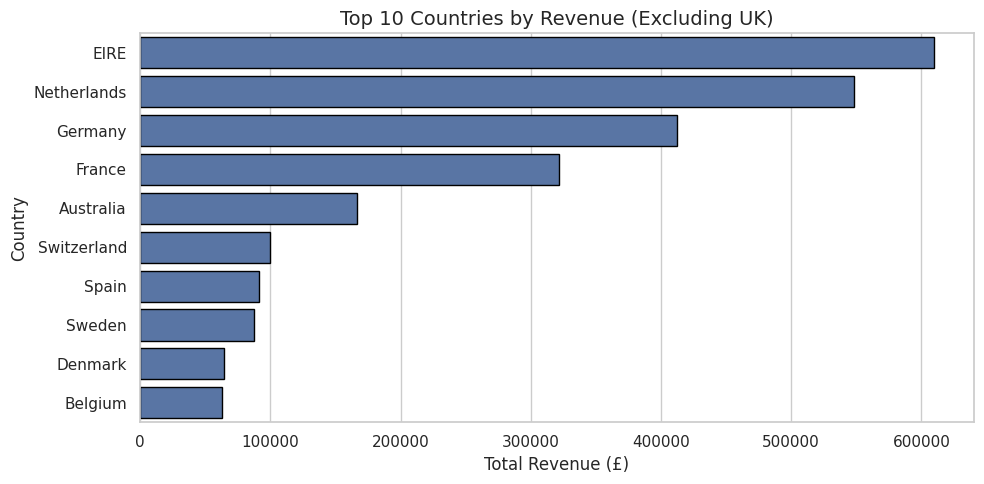

In [115]:
# Top 10 Revenue by Country (Excluding UK)

top_countries = by_country_revenue.drop('United Kingdom').head(10)

sns.barplot(x=top_countries.values, y=top_countries.index, linewidth=1, edgecolor="black", orient='h')
plt.title('Top 10 Countries by Revenue (Excluding UK)')
plt.xlabel('Total Revenue (£)')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig("../outputs/figures/revenue_by_country.png",
            dpi=150, bbox_inches='tight')
plt.show()

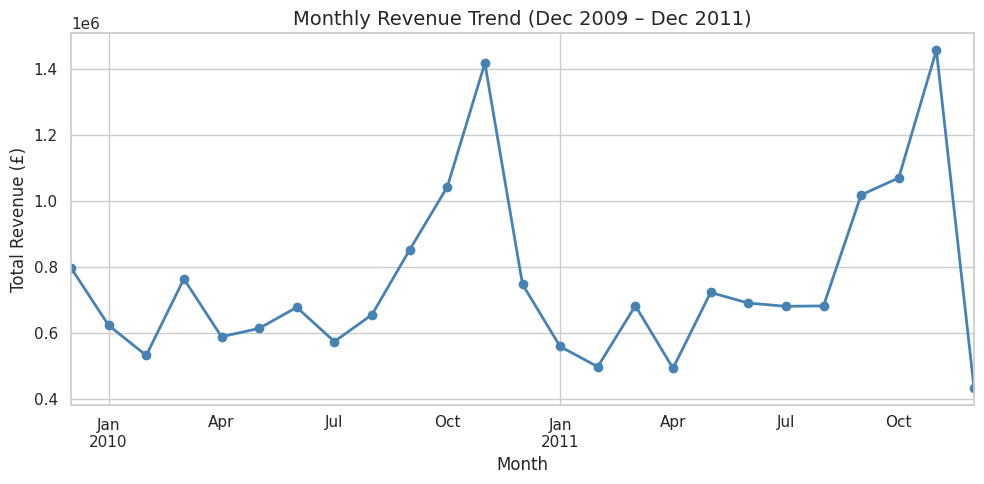

In [116]:
# Monthly Revenue Trend
monthly.plot(marker='o', linewidth=2, color="steelblue")
plt.title("Monthly Revenue Trend (Dec 2009 – Dec 2011)")
plt.xlabel("Month")
plt.ylabel("Total Revenue (£)")
plt.tight_layout()
plt.savefig("../outputs/figures/monthly_revenue_trend.png",
                dpi=150, bbox_inches='tight')
plt.show()

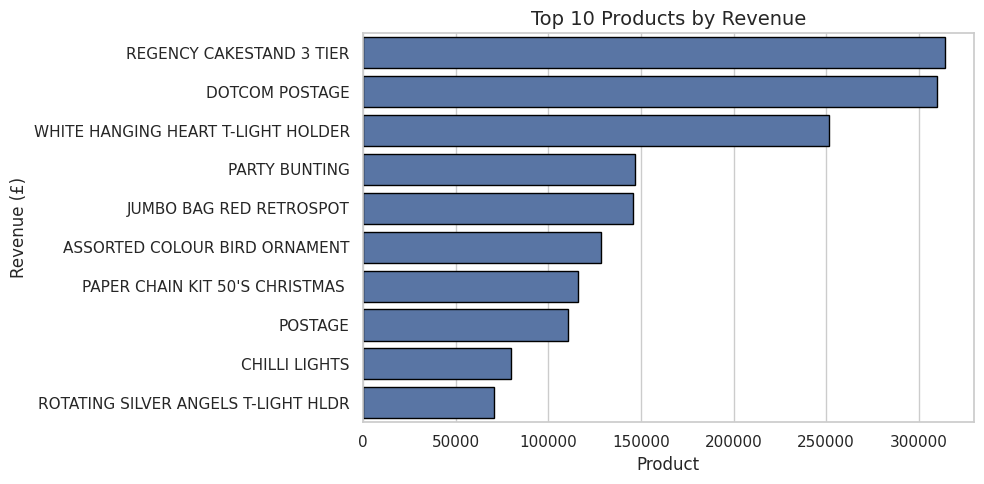

In [117]:
# Top 10 Products by Revenue
top_products = df.groupby('description')['revenue'].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_products.values, y=top_products.index, orient='h', linewidth=1, edgecolor="black")
plt.title('Top 10 Products by Revenue')
plt.xlabel('Product')
plt.ylabel("Revenue (£)")
plt.tight_layout()
plt.savefig("../outputs/figures/top_products_revenue.png",
            dpi=150, bbox_inches='tight')
plt.show()

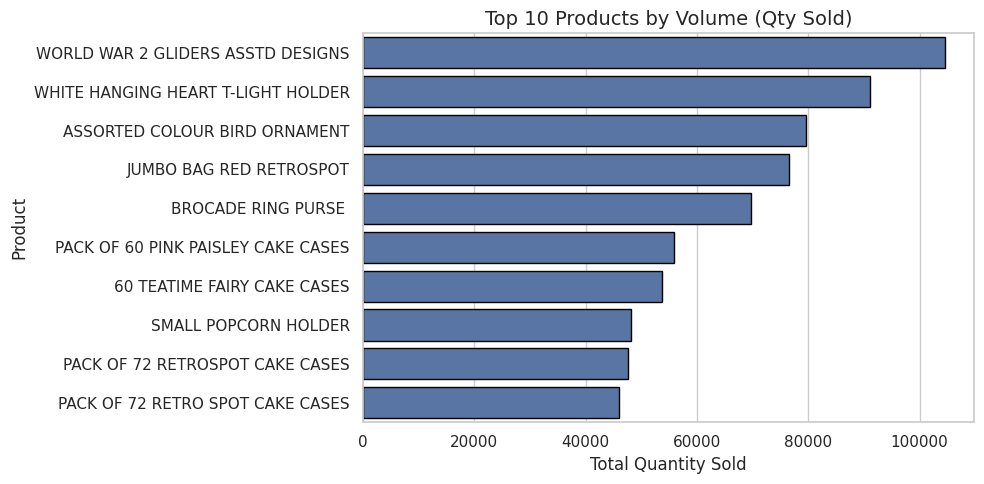

In [118]:
# Top 10 Products by Volume

top_products_qty = df.groupby('description')['quantity'].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_products_qty.values, y=top_products_qty.index, orient='h', linewidth=1, edgecolor="black")
plt.title('Top 10 Products by Volume (Qty Sold)')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')
plt.tight_layout()
plt.savefig('../outputs/figures/top_products_volume.png', dpi=150, bbox_inches='tight')
plt.show()

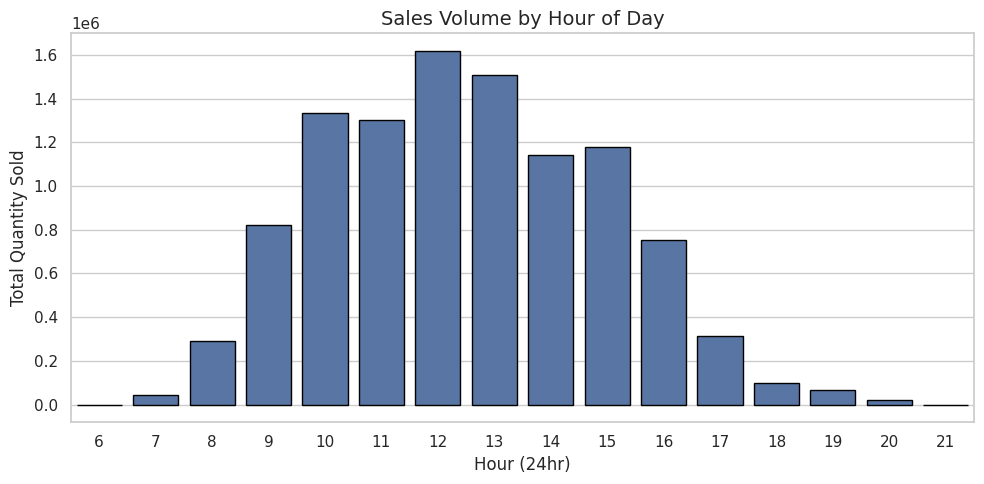

In [119]:
# Sales Volume by Hour of Day

by_hour_sorted = by_hour.sort_index()

sns.barplot(x=by_hour_sorted.index, y=by_hour_sorted.values, linewidth=1, edgecolor="black")
plt.title('Sales Volume by Hour of Day')
plt.xlabel('Hour (24hr)')
plt.ylabel("Total Quantity Sold")
plt.tight_layout()
plt.savefig("../outputs/figures/sales_by_hour.png",
            dpi=150, bbox_inches='tight')
plt.show()

In [120]:
# Anomaly Detection — Cancellations and Negative Quantities

cancellations = df[df['invoice'].astype(str).str.startswith('C')]

print(f"Total cancelled transactions: {len(cancellations):,}")
print(f"Revenue impact of cancellations: £ {cancellations['revenue'].sum():,.2f}")

negative_qty = df[df['quantity'] < 0]
print(f"\nTransactions with negative quantity: {len(negative_qty):,}")
print(f"Revenue impact of negative quantities: £ {negative_qty['revenue'].sum():,.2f}")

Total cancelled transactions: 19,104
Revenue impact of cancellations: £ -1,462,050.61

Transactions with negative quantity: 19,863
Revenue impact of negative quantities: £ -1,462,424.18


## Saving Cleaned Data & Summary Tables

In [121]:
# Saving a Copy Of The Cleaned Data
df.reset_index().to_csv("../data/processed/sales_analysis_cleaned.csv", index=False)


# Summary Tables
by_country_revenue.to_csv("../data/processed/by_country_revenue.csv")
top_products.to_csv("../data/processed/top_products_rev.csv")
top_products_qty.to_csv("../data/processed/top_products_qty.csv")
by_hour.to_csv("../data/processed/by_hour.csv")
monthly.to_csv("../data/processed/monthlytotals.csv")


print('All Processed Data and Summaries Saved')

All Processed Data and Summaries Saved


## Report

In [122]:
# Generate report text

report = f"""
--- Online Retail Sales Analysis ---

Date: {pd.Timestamp.now().strftime('%B %d, %Y')}
Dataset: UCI Online Retail II (Dec 2009 – Dec 2011)
Records Analyzed: {len(df):,}



--- Findings ---
Highest Revenue Country (Outside UK): {top_countries.index[0]} (£{top_countries.values[0]:,.2f})
Lowest Revenue Country (Outside UK): {by_country_revenue.index[-1]} (£{by_country_revenue.values[-1]:,.2f})

Top Product By Revenue: {top_products.index[0]} (£{top_products.values[0]:,.2f})
Top Product By Quantity Sold: {top_products_qty.index[0]} ({top_products_qty.values[0]:,})

Peak Sales Hour: {by_hour.index[0]}:00
Slowest Sales Hour: {by_hour.index[-1]}:00


The sales volume by hour of day follows a normal distribution.
Peak sales volume is around 12:00 pm and the slowest sales volume is in the early morning hours.
Since values are negative during the early morning hours, it suggests these might be cancellations or returns.



--- Summary Statistics ---
Total Revenue (Dec 2009 – Dec 2011): £{df_clean['revenue'].sum():,.2f}
Mean Revenue: £{mean_revenue:,.2f}
Median Revenue: £{median_revenue:,.2f}
Standard Deviation: £{std_revenue:,.2f}

Total Units Sold (Dec 2009 – Dec 2011): {df_clean['quantity'].sum():,}
Mean Quantity: {mean_qty:,.2f}
Median Quantity: {median_qty:,.2f}
Standard Deviation: {std_qty:,.2f}


The statistics for revenue and units sold follow a right skewed distribution. 
The gaps between mean and median show that large purchases are driving the mean higher than the median.
The standard deviations of both are also quite large. 

While most purchases are small in value, a few large purchases are significantly impacting the overall statistics.
The data suggests that these larger purchases are bulk orders from wholesale customers which skews the overall distribution.


--- Cancellations ---
Cancelled Transactions: {len(cancellations):,}
Revenue Impact of Cancellations: £{cancellations['revenue'].sum():,.2f}



--- Actionable Insights ---
- Focus marketing outside the UK to target the top 10 international countries with highest revenue.
- Countries with very low or negative revenue, consider removing them from your marketing efforts.
- Ensure highest revenue and volume products have strong inventory, especially during peak hours and peak months. 
- Investigate cancellation patterns to reduce revenue loss.


"""


with open("../outputs/reports/sales_report.txt", "w") as f:
    f.write(report)

print("Report Saved")


Report Saved
